<a href="https://colab.research.google.com/github/Nikhil5566/EDA-Repo/blob/main/UntitlFood_Nutrition_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Food Nutrition Dataset


# About this dataset

 Dataset, named 'Food_Nutrition_Dataset.csv', provides nutritional information for 205 different food items across 61 distinct categories. Each entry details the food_name, category, calories, protein, carbs, fat, iron, and vitamin_c content.

Initial data inspection revealed that food_name and category are categorical features, while the remaining columns represent numerical nutritional values. The dataset is relatively clean, with no duplicate entries. However, minor missing values were identified in the iron (2 entries) and vitamin_c (3 entries) columns, which would need to be addressed for a complete analysis.

Univariate analysis showed a wide range in nutritional content. For instance, calorie counts vary significantly, from a low of 16 to a high of 1460, with an average around 243. Proteins, carbohydrates, and fats also exhibit diverse distributions, often skewed towards lower values, indicating a mix of nutrient-dense and lighter food options. 'Fruits and Fruit Juices' and 'Vegetables and Vegetable Products' emerged as the most represented food categories.

Exploring relationships between numerical features through scatter plots and a correlation matrix highlighted strong positive correlations between calories and the macronutrients (protein, carbs, fat). This is an expected finding, as these components directly contribute to a food's caloric value. Conversely, micronutrients like iron and vitamin_c showed weaker, less direct correlations with other nutritional metrics, suggesting their presence is more varied and less dependent on overall macronutrient content. The box plots, though not explicitly detailed here, would further illustrate how these nutritional profiles differ across the various food categories, offering granular insights into the nutrient composition of different food groups.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')

In [2]:
!pip install -q kaggle

# Uploading kaggle.json
from google.colab import files
files.upload()

# Moving kaggle.json to ~/.kaggle/
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Downloading the dataset using Kaggle API
!kaggle datasets download -d sonalshinde123/food-nutrition-dataset-150-everyday-foods

# Unziping the downloaded file
!unzip food-nutrition-dataset-150-everyday-foods.zip

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/sonalshinde123/food-nutrition-dataset-150-everyday-foods
License(s): CC0-1.0
  0% 0.00/5.44k [00:00<?, ?B/s]
100% 5.44k/5.44k [00:00<00:00, 20.1MB/s]
Archive:  food-nutrition-dataset-150-everyday-foods.zip
  inflating: Food_Nutrition_Dataset.csv  


In [3]:
df = pd.read_csv('Food_Nutrition_Dataset.csv')
df.head(11)

,food_name,category,calories,protein,carbs,fat,iron,vitamin_c
0,"Apple, candied",Apples,134.0,1.34,29.61,2.15,0.12,3.6
1,"Apple, raw",Apples,61.0,0.17,14.80,0.15,0.03,4.6
2,"Apple, dried",Dried fruits,243.0,0.93,65.89,0.32,1.40,3.9
3,"Crisp, apple",Cakes and pies,215.0,2.81,30.18,9.59,1.00,0.6
4,"Apple, baked",Apples,113.0,0.32,22.70,3.08,0.19,3.9
5,Apple cider,Apple juice,46.0,0.10,11.30,0.13,0.12,0.9
6,"Cobbler, apple",Cakes and pies,217.0,2.05,33.56,8.66,0.98,0.6
7,"Croissants, apple",Baked Products,1060.0,7.40,37.10,8.70,1.10,0.5
8,"Pie, apple",Cakes and pies,296.0,2.70,37.55,15.28,1.23,0.5
9,"Strudel, apple",Cakes and pies,281.0,1.96,37.18,14.08,0.30,0.5


In [4]:
df.tail(11)

,food_name,category,calories,protein,carbs,fat,iron,vitamin_c
194,"Garlic bread, from frozen",Yeast breads,350.0,8.36,41.72,16.61,3.05,0.2
195,"PIZZA HUT, breadstick, parmesan garlic",Fast Foods,1430.0,12.20,44.50,12.90,4.65,NaN
196,"Garlic bread, from fast food / restaurant",Yeast breads,349.0,8.34,41.64,16.58,3.04,0.2
197,"Garlic bread, with melted cheese, from frozen",Yeast breads,343.0,10.36,36.86,17.10,2.68,0.2
198,"Garlic bread, with parmesan cheese, from frozen",Yeast breads,351.0,8.78,41.14,16.83,3.00,0.2
199,"Shrimp in garlic sauce, Puerto Rican style",Seafood mixed dishes,281.0,11.56,2.45,24.96,0.41,12.0
200,"Garlic bread, with parmesan cheese, from fast ...",Yeast breads,351.0,8.76,41.06,16.80,2.99,0.2
201,"Garlic bread, with melted cheese, from fast fo...",Yeast breads,339.0,11.41,34.21,17.34,2.48,0.2
202,"Fast foods, breadstick, soft, prepared with ga...",Fast Foods,1430.0,12.20,44.50,12.90,4.65,0.0
203,"HORMEL ALWAYS TENDER, Pork Loin Filets, Lemon ...",Pork Products,492.0,17.80,1.79,4.16,0.60,1.7


In [5]:
df.shape

(205, 8)

In [6]:
df.columns

Index(['food_name', 'category', 'calories', 'protein', 'carbs', 'fat', 'iron',
       'vitamin_c'],
      dtype='object')

In [7]:
df.dtypes

,0
food_name,object
category,object
calories,float64
protein,float64
carbs,float64
fat,float64
iron,float64
vitamin_c,float64


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   food_name  205 non-null    object 
 1   category   205 non-null    object 
 2   calories   205 non-null    float64
 3   protein    205 non-null    float64
 4   carbs      205 non-null    float64
 5   fat        205 non-null    float64
 6   iron       203 non-null    float64
 7   vitamin_c  202 non-null    float64
dtypes: float64(6), object(2)
memory usage: 12.9+ KB


In [10]:
df.describe(include = 'all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
food_name,205,205,"Apple, candied",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category,205,61,Fruits and Fruit Juices,23,NaN,NaN,NaN,NaN,NaN,NaN,NaN
calories,205.0,NaN,NaN,NaN,243.790244,283.580451,16.0,62.0,166.0,296.0,1460.0
protein,205.0,NaN,NaN,NaN,2.852829,3.357243,0.0,0.64,1.71,3.2,17.8
carbs,205.0,NaN,NaN,NaN,25.573366,20.119102,1.79,11.2,17.22,37.55,85.13
fat,205.0,NaN,NaN,NaN,6.018,9.694549,0.0,0.2,1.18,9.39,74.02
iron,203.0,NaN,NaN,NaN,0.85133,1.103369,0.0,0.205,0.41,1.08,9.09
vitamin_c,202.0,NaN,NaN,NaN,13.694554,18.503094,0.0,1.625,7.45,17.375,136.0


In [11]:
df.isnull().sum()

,0
food_name,0
category,0
calories,0
protein,0
carbs,0
fat,0
iron,2
vitamin_c,3


In [12]:
df.duplicated().sum()

np.int64(0)

# Univariate Analysis

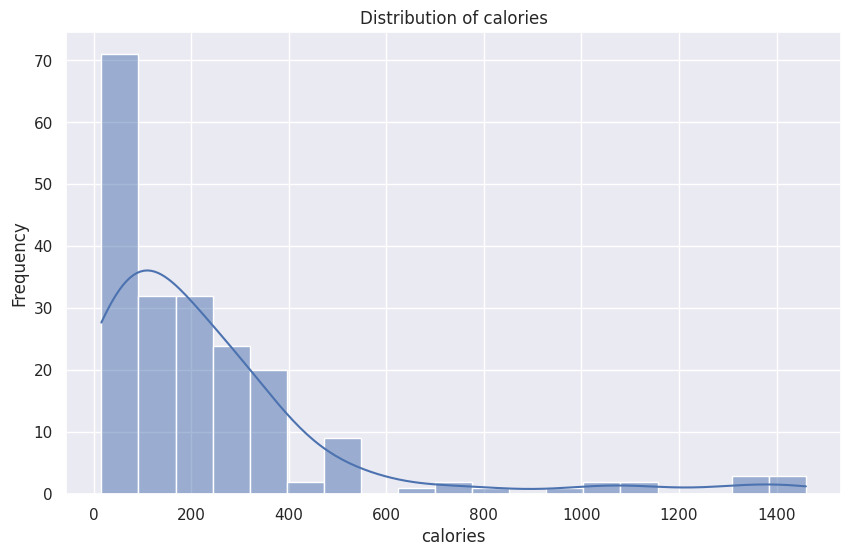

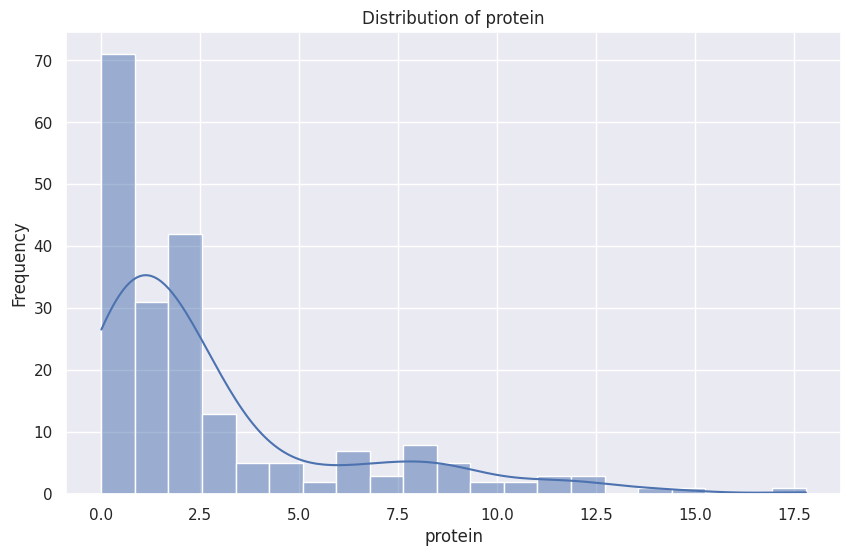

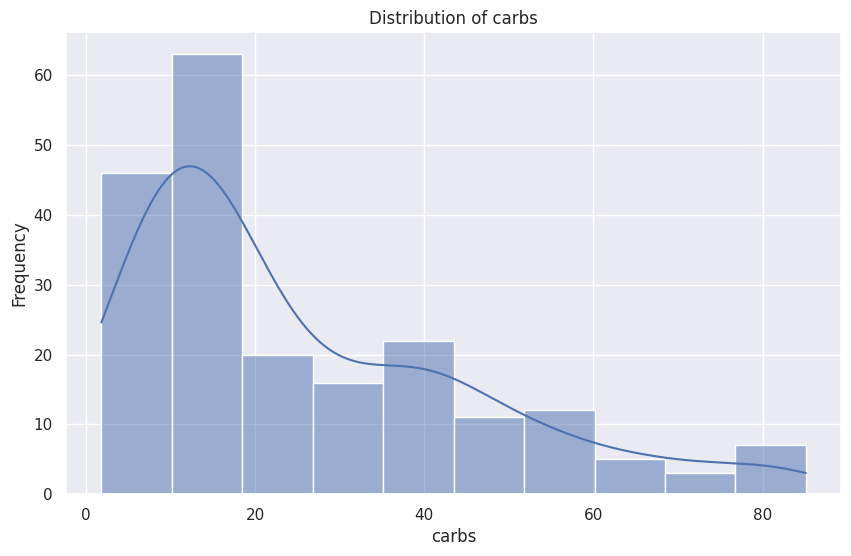

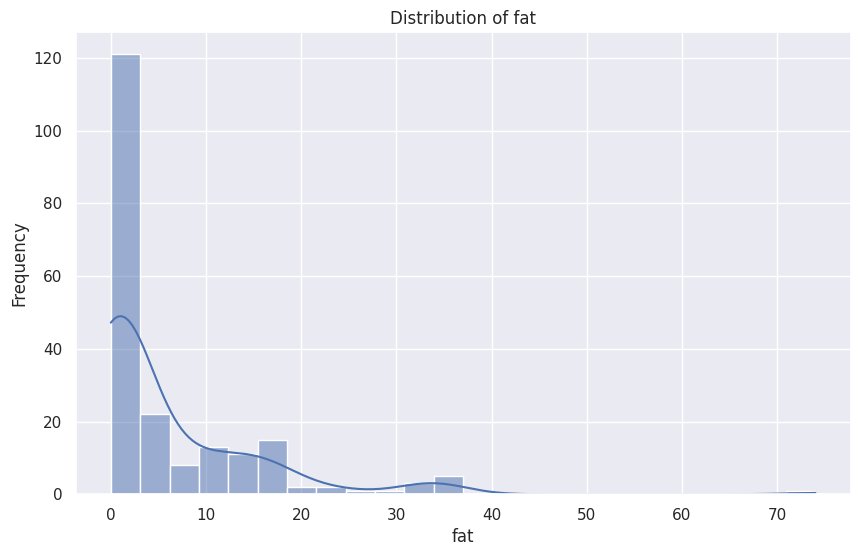

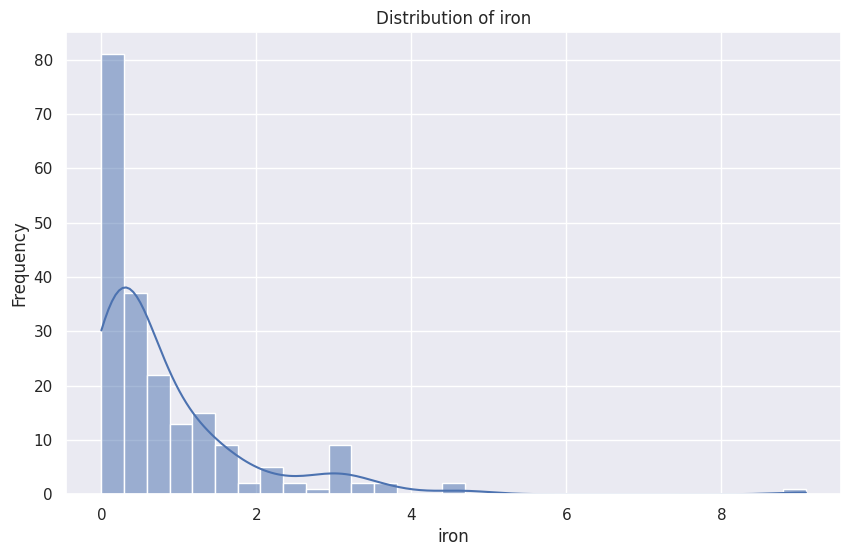

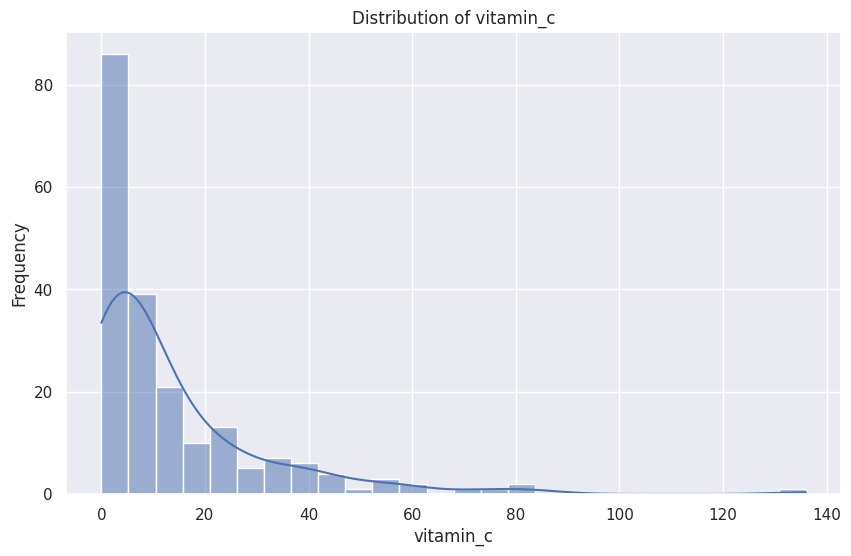

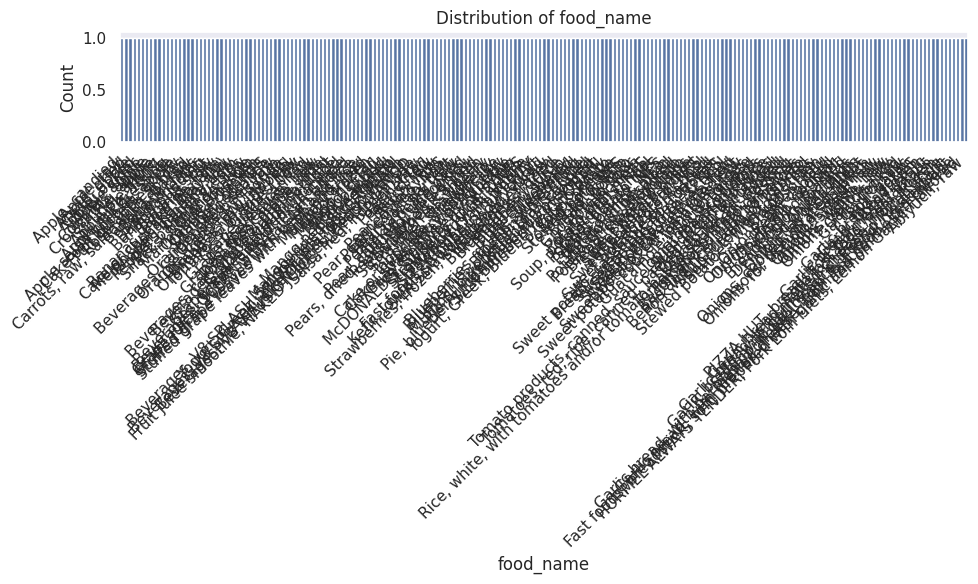

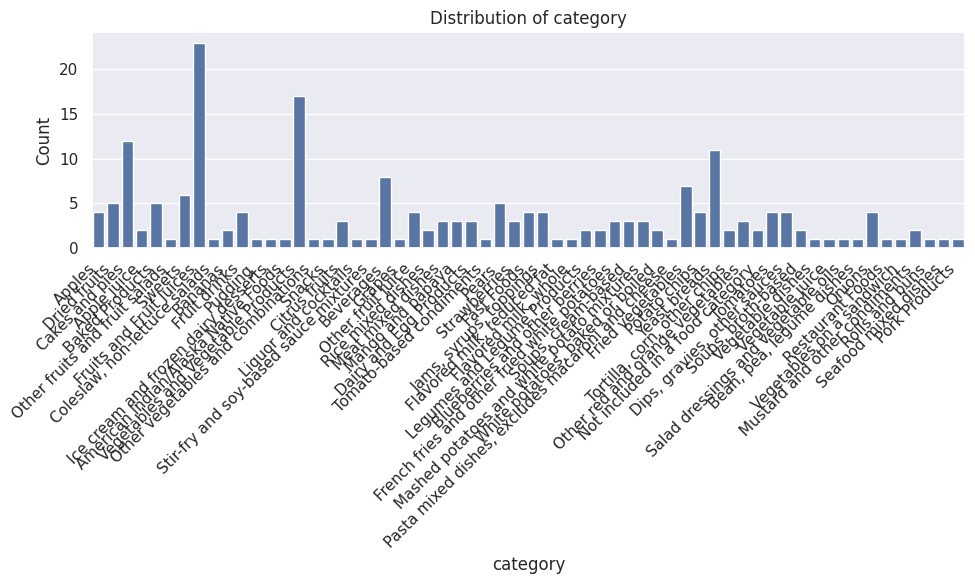

Value counts for food_name:
food_name
Apple, candied                                                            1
Apple, raw                                                                1
Apple, dried                                                              1
Crisp, apple                                                              1
Apple, baked                                                              1
                                                                         ..
Garlic bread, with parmesan cheese, from fast food / restaurant           1
Garlic bread, with melted cheese, from fast food / restaurant             1
Fast foods, breadstick, soft, prepared with garlic and parmesan cheese    1
HORMEL ALWAYS TENDER, Pork Loin Filets, Lemon Garlic-Flavored             1
Abiyuch, raw                                                              1
Name: count, Length: 205, dtype: int64

Value counts for category:
category
Fruits and Fruit Juices              23
Vegetables

In [13]:
# Getting a list of numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterating through numerical columns and create histograms
for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

# Getting a list of categorical columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()

# Iterate through categorical columns and create countplots
for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x=col)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# We can also use value_counts for a quick look at categorical data distribution
for col in categorical_cols:
    print(f"Value counts for {col}:\n{df[col].value_counts()}\n")

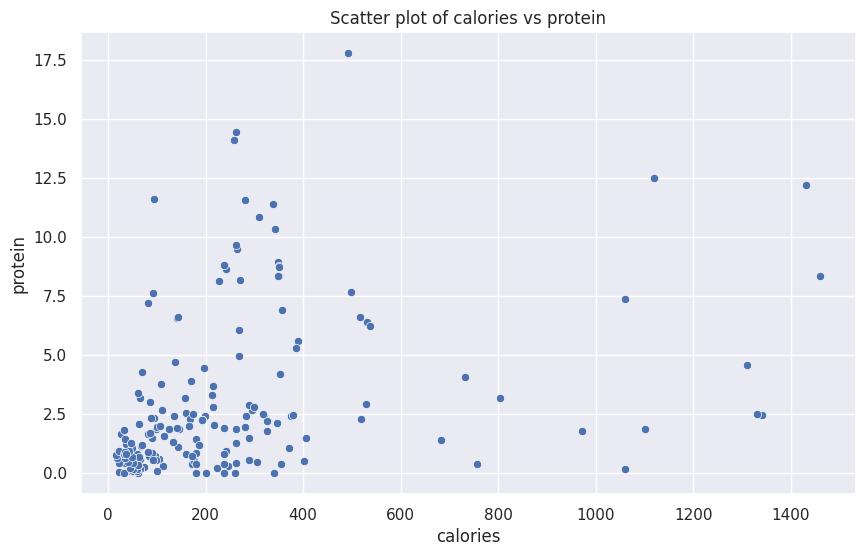

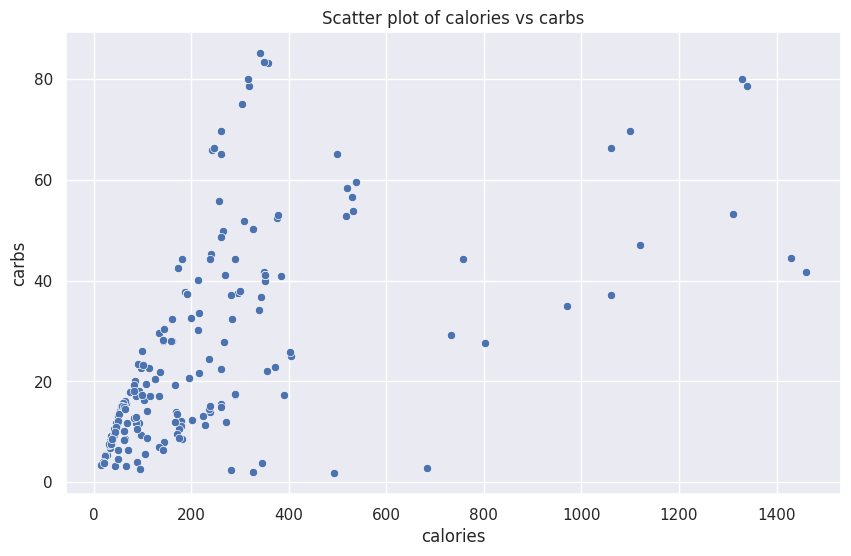

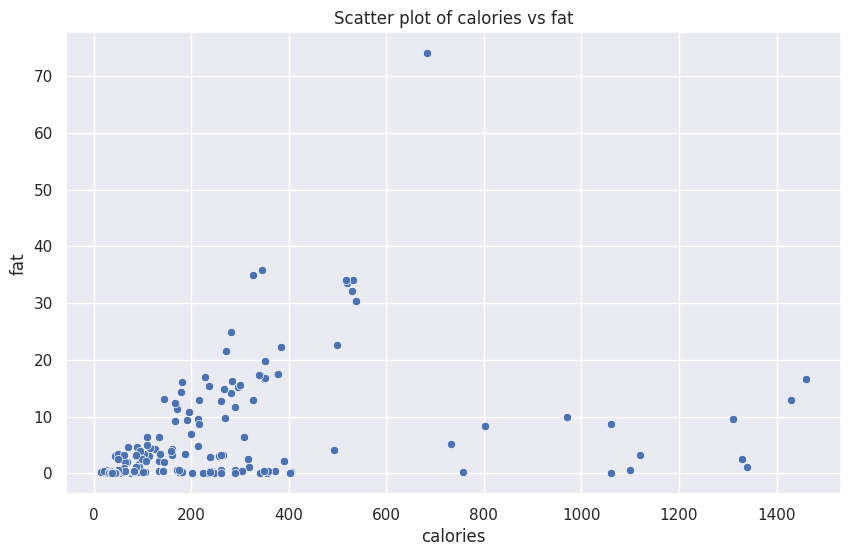

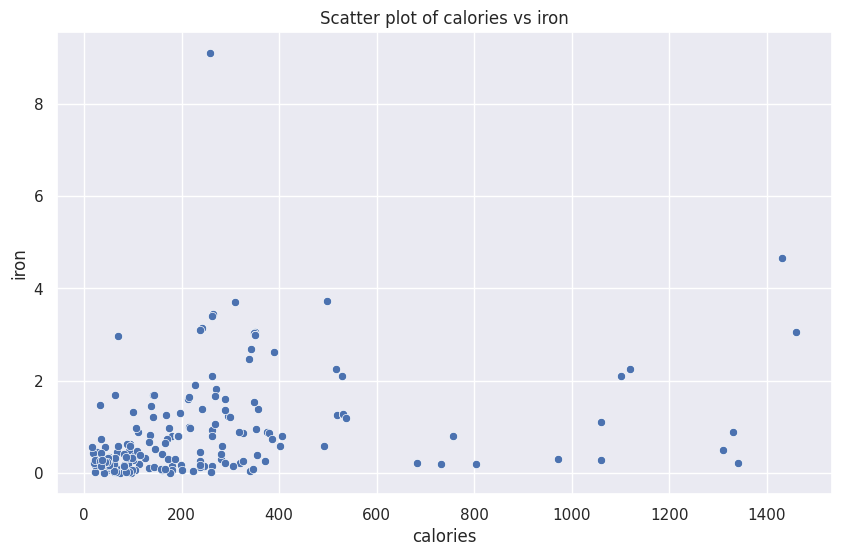

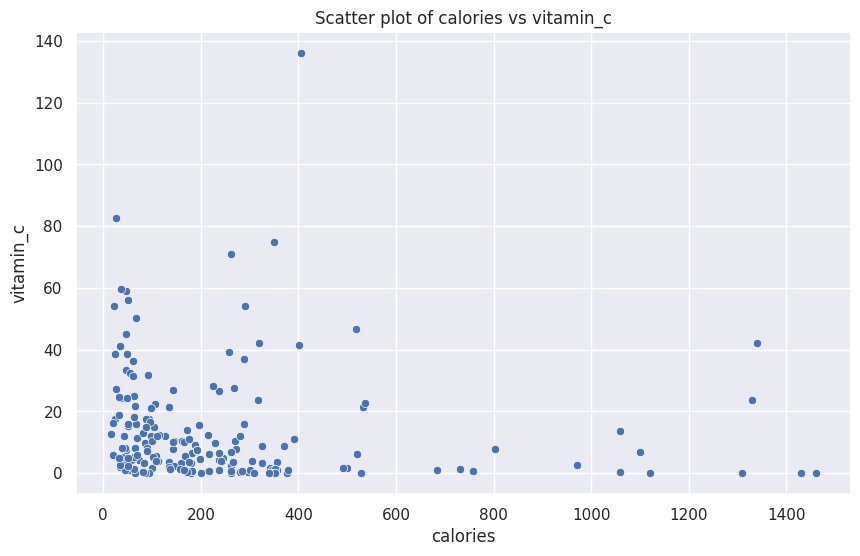

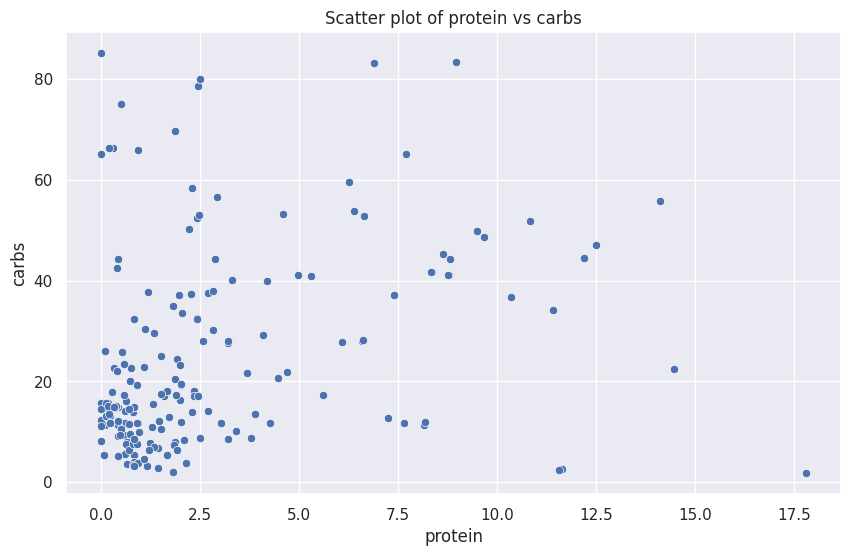

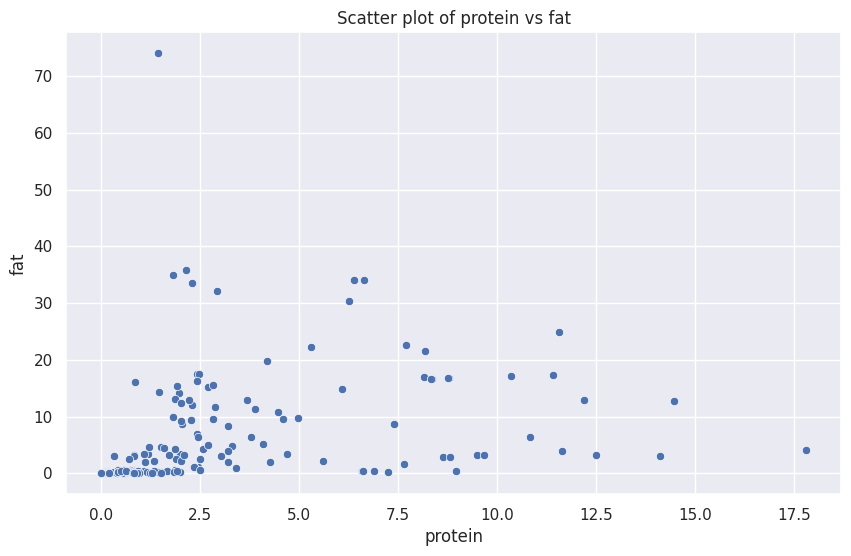

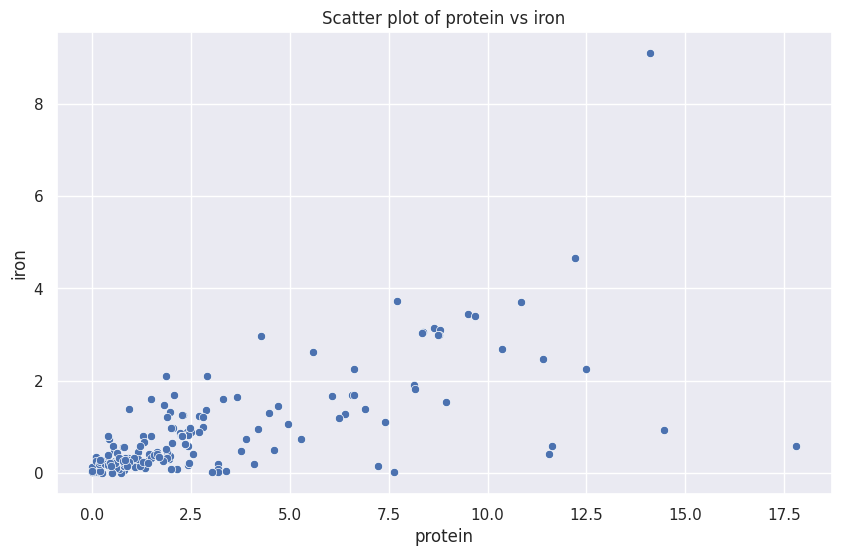

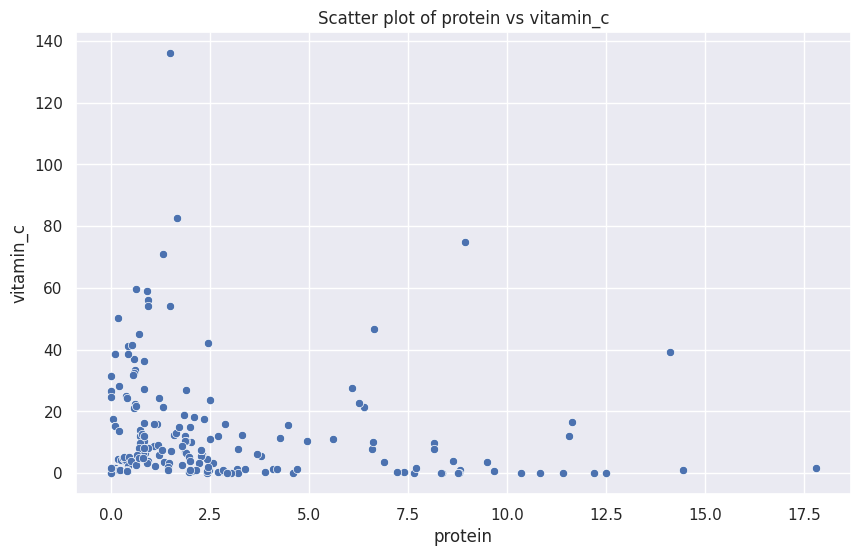

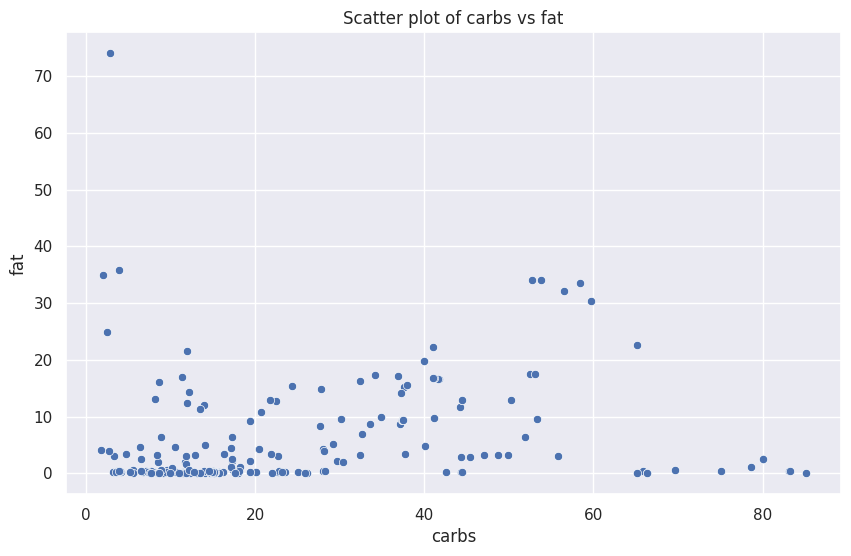

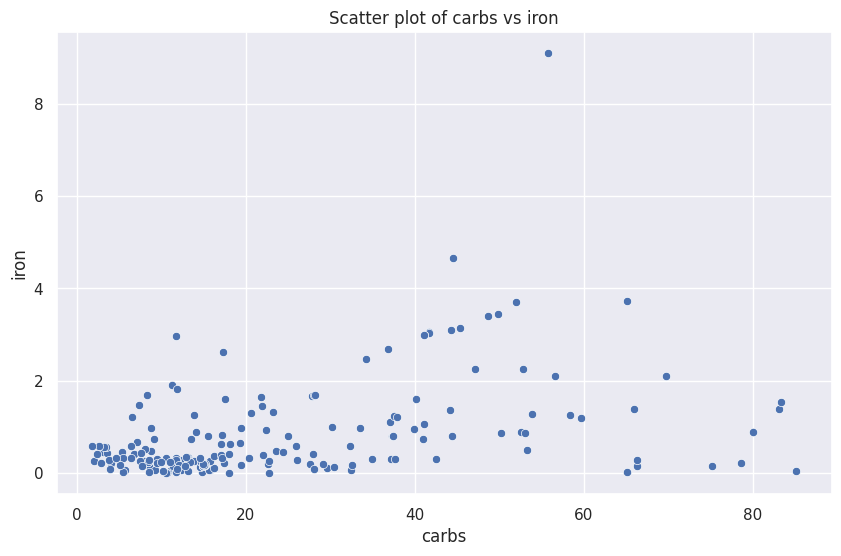

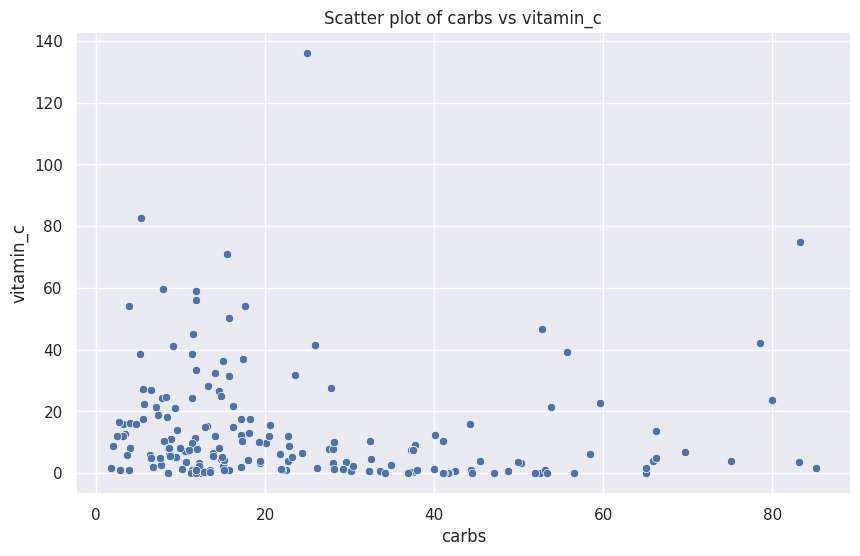

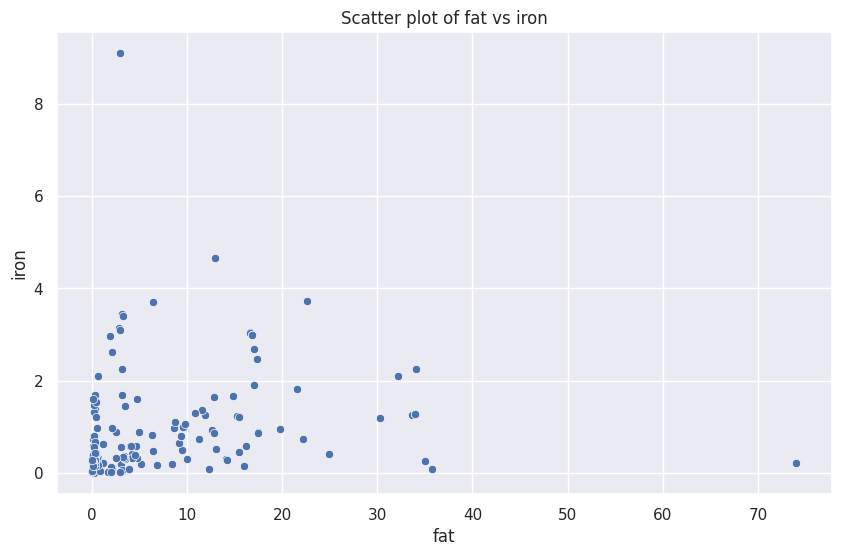

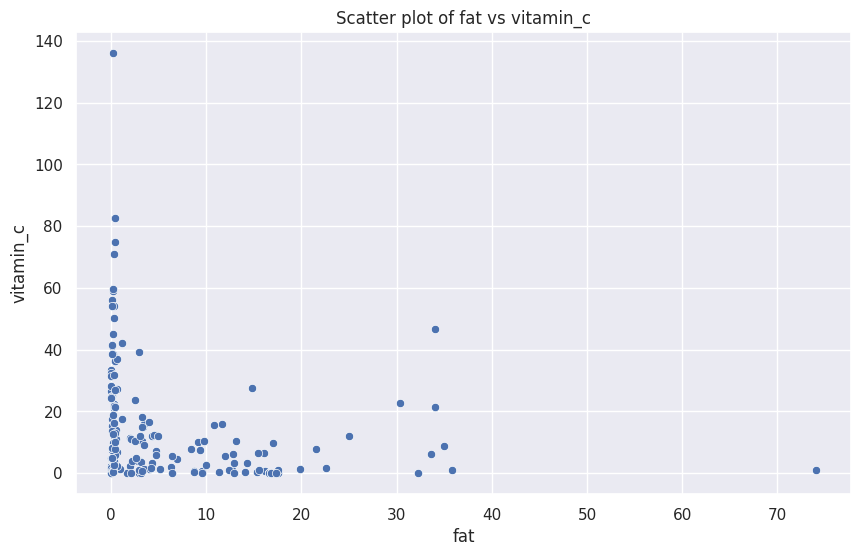

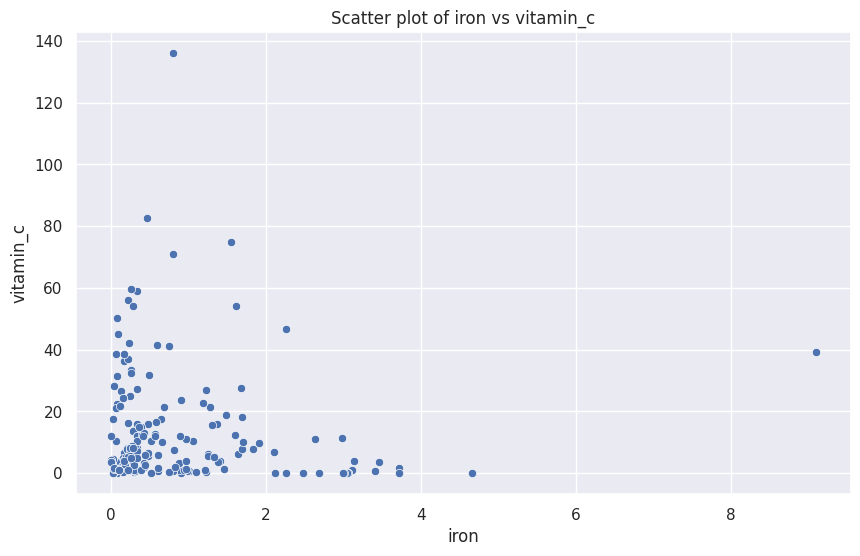

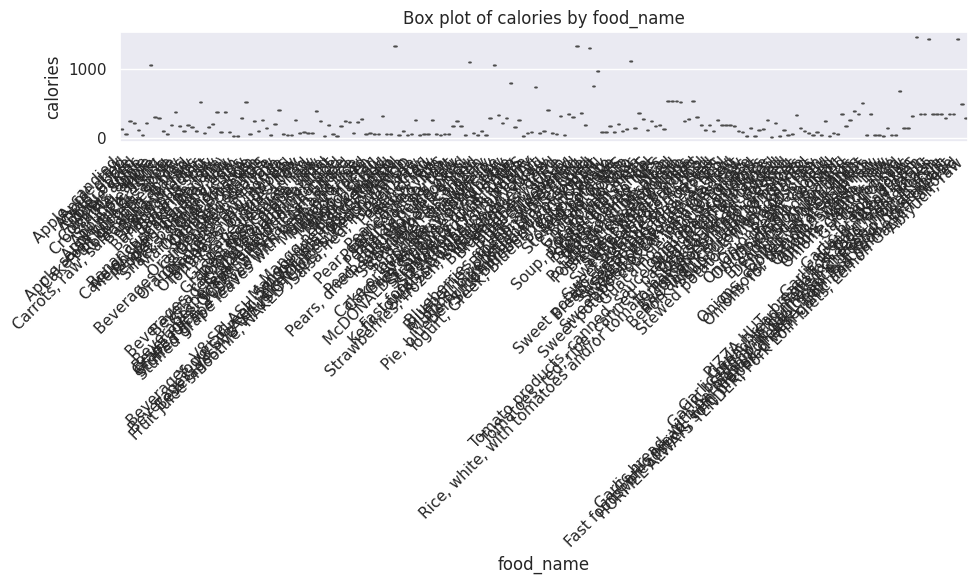

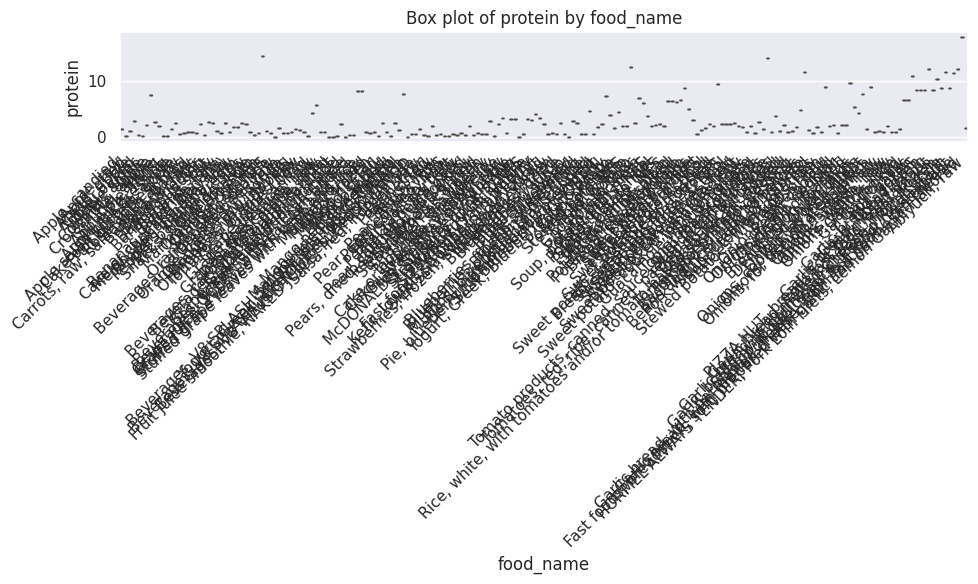

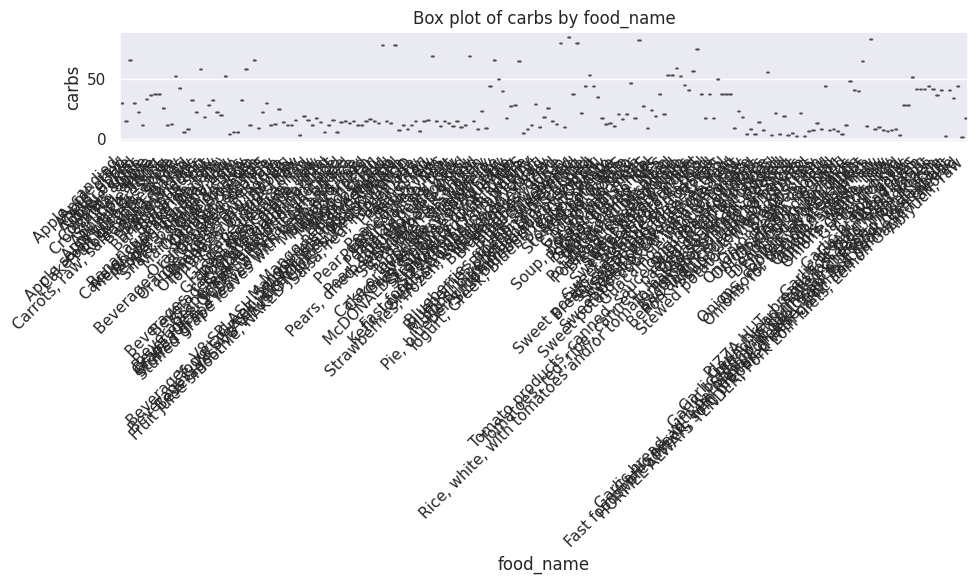

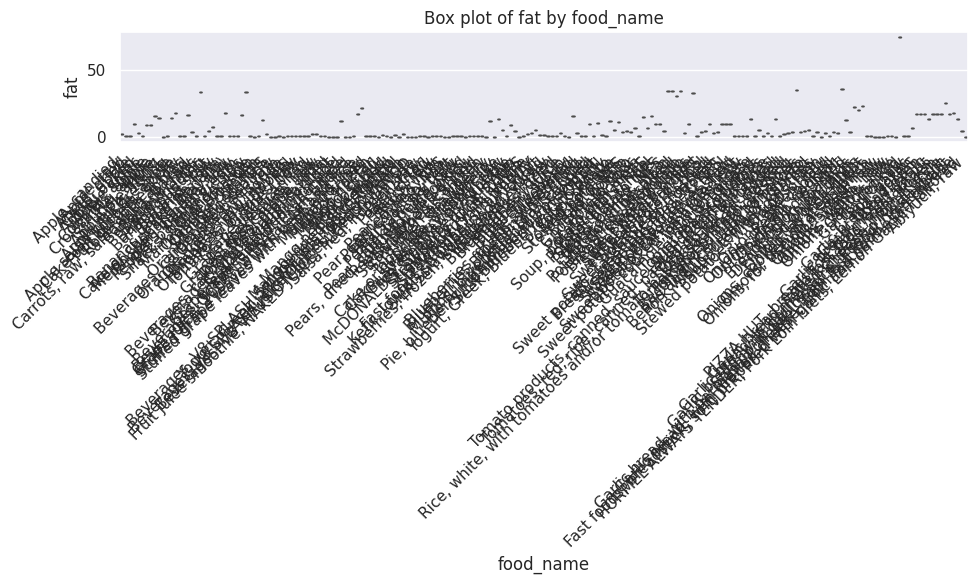

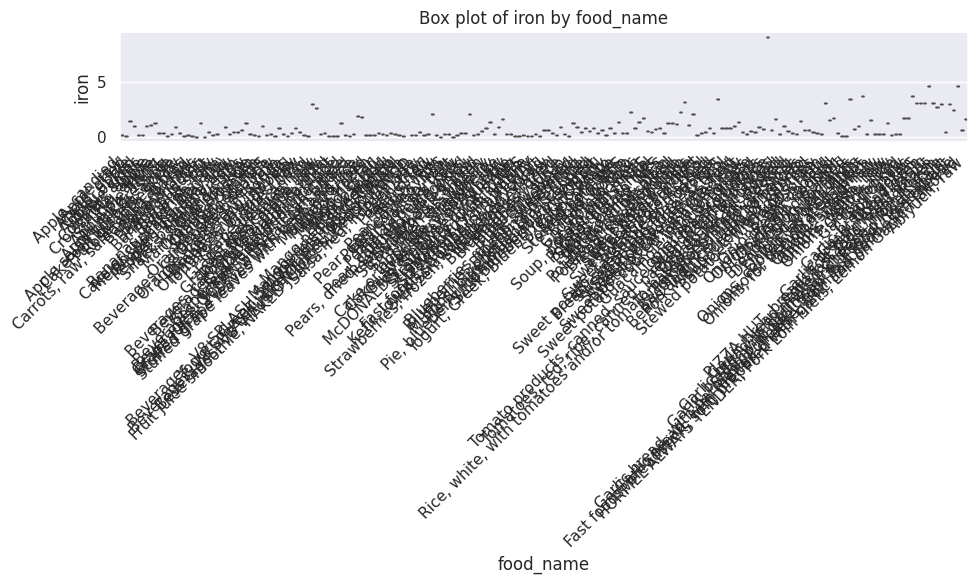

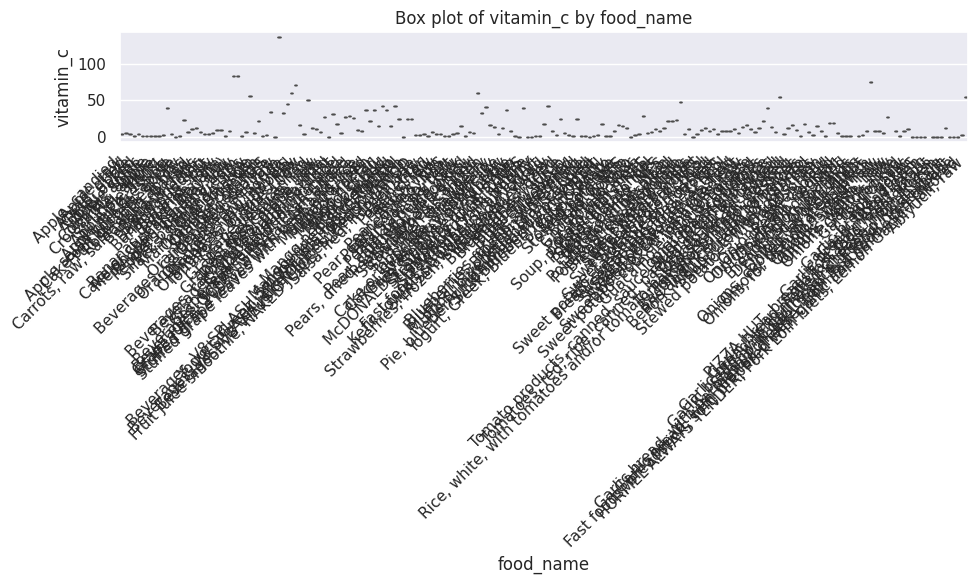

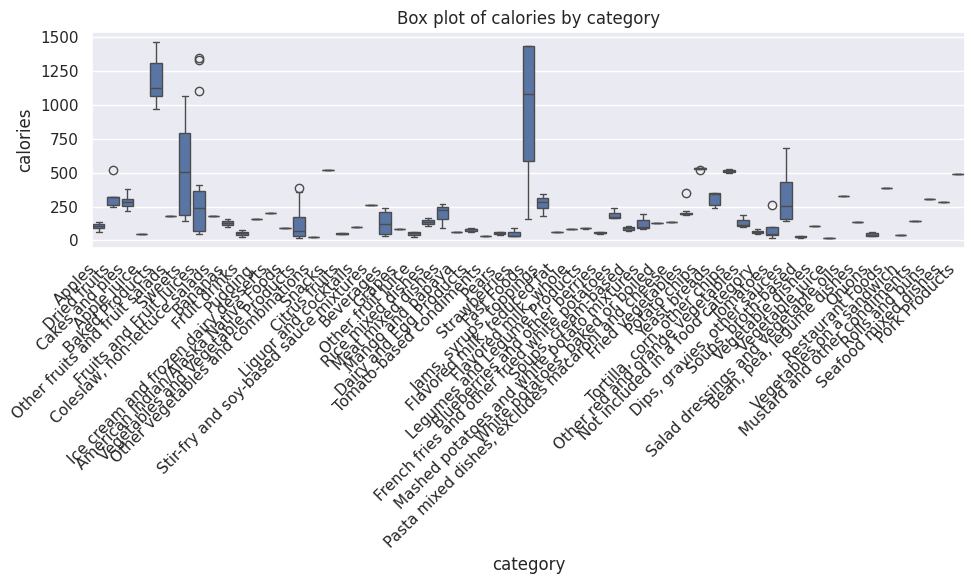

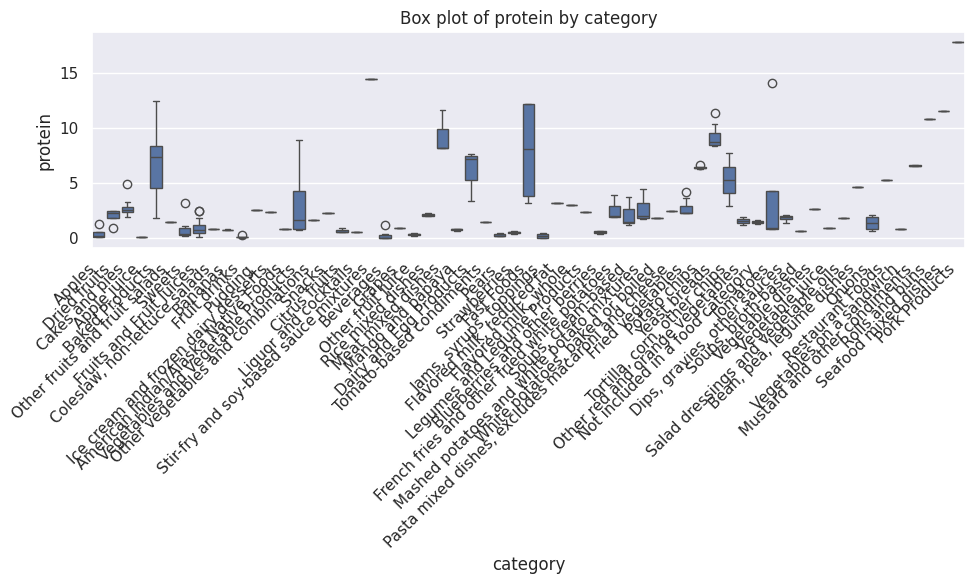

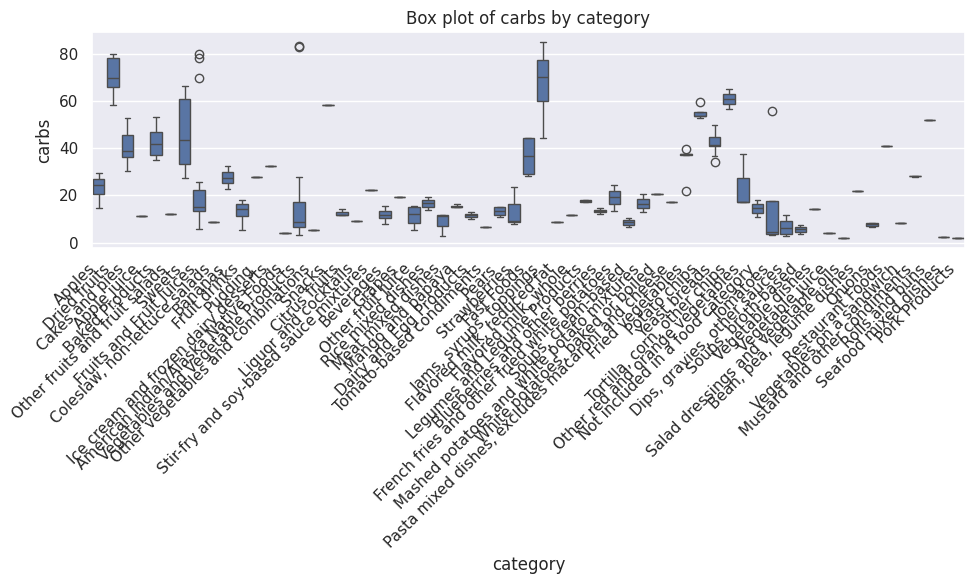

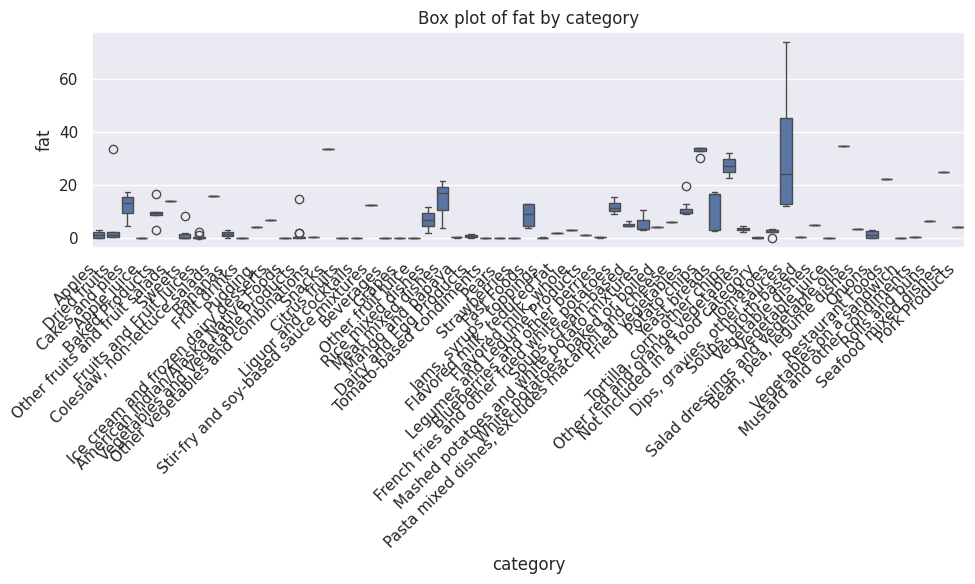

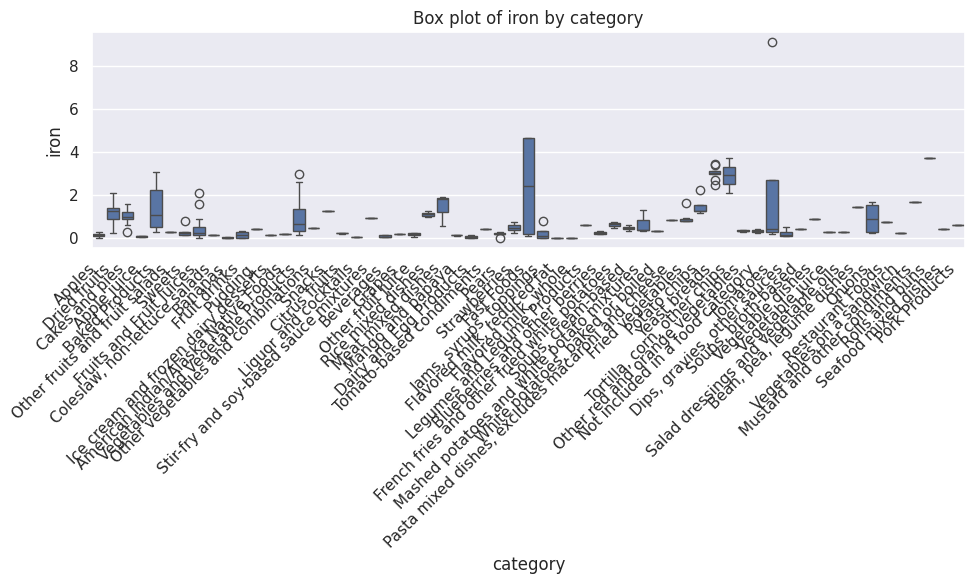

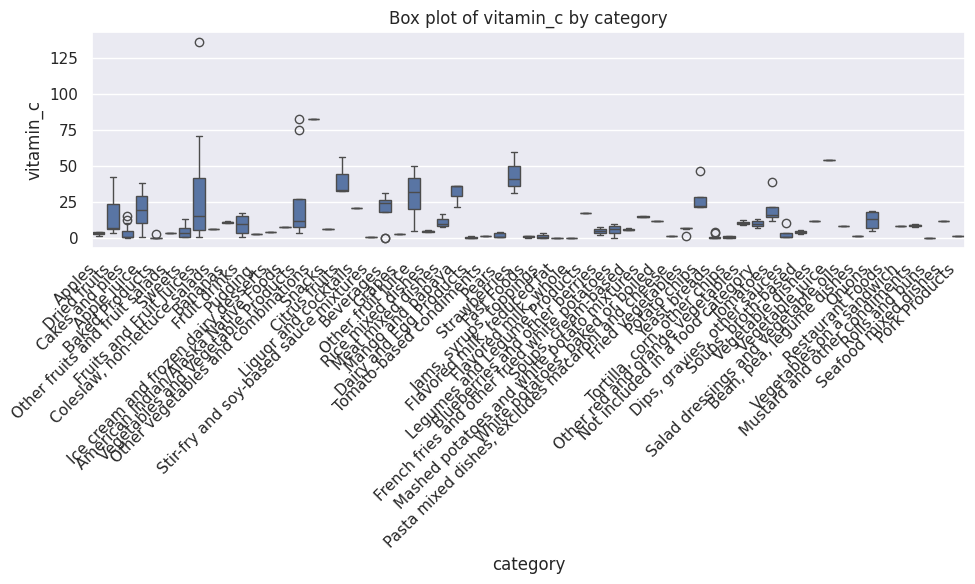

In [14]:
# Numerical-Numerical relationships (Scatter plots)
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through pairs of numerical columns and create scatter plots
for i in range(len(numerical_cols)):
    for j in range(i + 1, len(numerical_cols)):
        col1 = numerical_cols[i]
        col2 = numerical_cols[j]
        plt.figure(figsize=(10, 6))
        sns.scatterplot(data=df, x=col1, y=col2)
        plt.title(f'Scatter plot of {col1} vs {col2}')
        plt.xlabel(col1)
        plt.ylabel(col2)
        plt.show()

# Categorical-Numerical relationships (Box plots)
categorical_cols = df.select_dtypes(include='object').columns.tolist()
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through categorical and numerical columns and create box plots
for cat_col in categorical_cols:
    for num_col in numerical_cols:
        plt.figure(figsize=(10, 6))
        sns.boxplot(data=df, x=cat_col, y=num_col)
        plt.title(f'Box plot of {num_col} by {cat_col}')
        plt.xlabel(cat_col)
        plt.ylabel(num_col)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

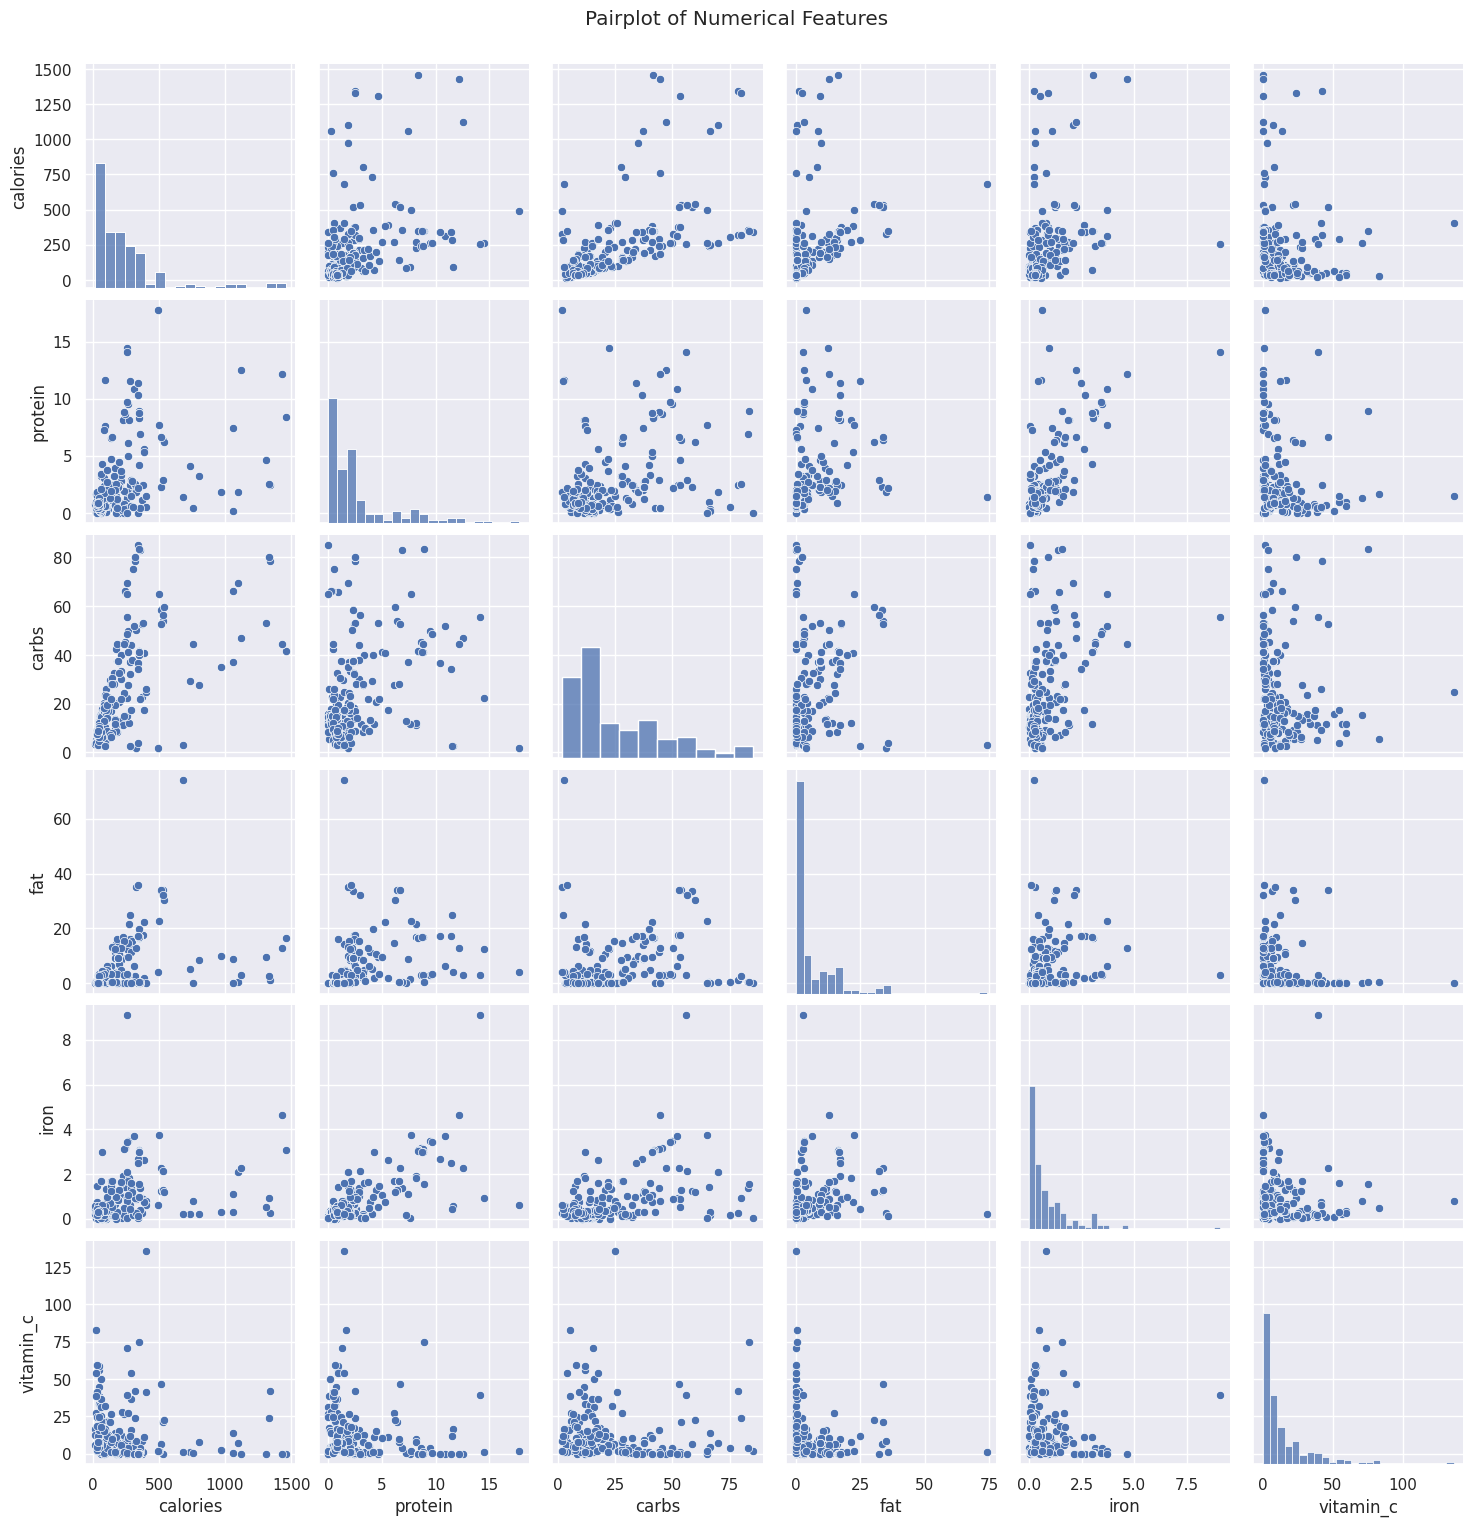

In [15]:
sns.pairplot(df.select_dtypes(include=np.number))
plt.suptitle('Pairplot of Numerical Features', y=1.02)
plt.show()

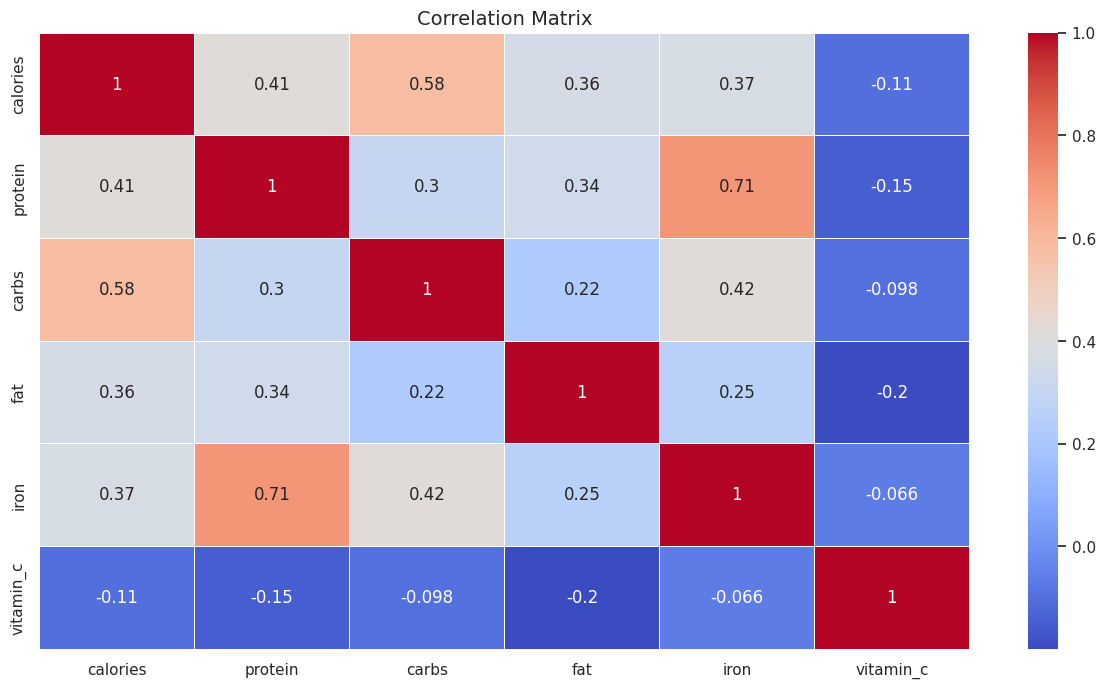

In [16]:
plt.figure(figsize=(15, 8))
sns.heatmap(df.corr(numeric_only = True), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix", fontsize=14)
plt.show()

# Thank you